# Pose Cluster Visualizations


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Ensure the output directory exists
os.makedirs('data/output', exist_ok=True)

# Load data
df = pd.read_csv('data/pose_clusters.csv')

# Constants for drawing the skeleton
BONES = [
    ['nose', 'neck'], ['neck', 'rshoulder'], ['neck', 'lshoulder'],
    ['rshoulder', 'relbow'], ['lshoulder', 'lelbow'],
    ['relbow', 'rwrist'], ['lelbow', 'lwrist'],
    ['neck', 'midhip'], ['midhip', 'rhip'], ['midhip', 'lhip'],
    ['rhip', 'rknee'], ['lhip', 'lknee'],
    ['rknee', 'rankle'], ['lknee', 'lankle'],
    ['rankle', 'rbigtoe'], ['lankle', 'bigtoe']
]
JOINTS = [
    'nose', 'neck', 'lshoulder', 'rshoulder', 'lelbow', 'relbow',
    'lwrist', 'rwrist', 'midhip', 'lhip', 'rhip', 'lknee', 'rknee',
    'lankle', 'rankle', 'bigtoe', 'rbigtoe'
]

# set colors
COLOR_WOMEN = '#FFA500' # Orange-yellow
COLOR_MEN = '#007A53'   # Teal-green
COLOR_NB = '#004A99'    # Dark blue

# === Summary Statistics ===
total_clusters = len(df)
significant_clusters = df[df['significant'] == 1].copy()
num_significant = len(significant_clusters)
total_poses = df['size'].sum()

print("== Analysis Summary for Report ==")
print(f"Total poses analyzed: {total_poses}")
print(f"Total clusters formulated: {total_clusters}")
print(f"Clusters demonstrating significant gender bias (p < 0.001/150): {num_significant}")
print("=================================")

# Calculate absolute counts per gender for internal bar labeling 
df['women_count'] = np.round(df['size'] * df['femalePercent'] / 100).astype(int)
df['men_count'] = np.round(df['size'] * df['malePercent'] / 100).astype(int)
df['nb_count'] = np.round(df['size'] * df['nonbinaryPercent'] / 100).astype(int)

significant_clusters['women_count'] = np.round(significant_clusters['size'] * significant_clusters['femalePercent'] / 100).astype(int)
significant_clusters['men_count'] = np.round(significant_clusters['size'] * significant_clusters['malePercent'] / 100).astype(int)
significant_clusters['nb_count'] = np.round(significant_clusters['size'] * significant_clusters['nonbinaryPercent'] / 100).astype(int)


== Analysis Summary for Report ==
Total poses analyzed: 15167
Total clusters formulated: 150
Clusters demonstrating significant gender bias (p < 0.001/150): 30


In [10]:
def plot_gender_distribution(dataframe, title="", filename=None, show_counts=True, highlight_significant=False):
    """
    dataframe: DataFrame with counts and percentages
    title: plot title
    filename: save path
    show_counts: bool to indicate if numbers should be displayed on bars
    highlight_significant: bool to fade out non-significant clusters
    """
    # Sort ascending by female percentage
    sorted_df = dataframe.sort_values('femalePercent', ascending=True).reset_index(drop=True)
    cluster_labels = sorted_df['cluster_id'].astype(str)
    
    women_pct = sorted_df['femalePercent'] / 100.0
    men_pct = sorted_df['malePercent'] / 100.0
    nb_pct = sorted_df['nonbinaryPercent'] / 100.0
    
    # Adapt width depending on number of columns
    width = 18 if len(sorted_df) > 50 else 12
    fig, ax = plt.subplots(figsize=(width, 8))
    
    bar_width = 0.9 if len(sorted_df) > 50 else 0.85
    ind = np.arange(len(sorted_df))
    
    p1 = ax.bar(ind, women_pct, bar_width, color=COLOR_WOMEN, edgecolor='none')
    p2 = ax.bar(ind, men_pct, bar_width, bottom=women_pct, color=COLOR_MEN, edgecolor='none')
    p3 = ax.bar(ind, nb_pct, bar_width, bottom=women_pct+men_pct, color=COLOR_NB, edgecolor='none')
    
    ax.set_xticks(ind)
    ax.set_xticklabels(cluster_labels, rotation=90, fontsize=max(6, 10 - (len(sorted_df)//25)))

    # highlight significant clusters by fading non-significant ones
    if highlight_significant and 'significant' in sorted_df.columns:
        # Get the labels we just created so we can edit their colors
        labels = ax.get_xticklabels()
        for i, row in sorted_df.iterrows():
            if not bool(row['significant']):
                p1[i].set_alpha(0.50) # Fade women segment
                p2[i].set_alpha(0.50) # Fade men segment
                p3[i].set_alpha(0.50) # Fade non-binary segment
                
                # Fade the x-axis label 
                labels[i].set_color("gray")
                
    # Determine font size for internal bar text
    fontsize = 11
        
    # Logic to show counts inside the bars
    if show_counts:
        for i, row in sorted_df.iterrows():
            ax.text(i, women_pct[i]/2, str(int(row['women_count'])), 
                    ha='center', va='center', rotation=90, color='black', fontsize=fontsize)
            
            ax.text(i, women_pct[i] + men_pct[i]/2, str(int(row['men_count'])), 
                    ha='center', va='center', rotation=90, color='white', fontsize=fontsize)
            
            ax.text(i, women_pct[i] + men_pct[i] + nb_pct[i]/2, str(int(row['nb_count'])), 
                    ha='center', va='center', rotation=90, color='white', fontsize=fontsize)

    # Rest of the formatting
    ax.set_ylim(0, 1.0)
    ax.set_xlim(-0.8, len(sorted_df) - 0.2)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    
    # Custom Legend
    ax.legend((p3[0], p2[0], p1[0]), ('non-binary', 'men', 'women'), 
              loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False)
              
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(axis='x', length=0)
    
    if title:
        fig.suptitle(title, fontsize=14, y=0.02)
        
    plt.tight_layout()
    if filename:
        plt.savefig(f"data/output/{filename}", dpi=600, bbox_inches='tight')
    plt.show()

### Distribution of gender across all 150 clusters sorted by the share of women

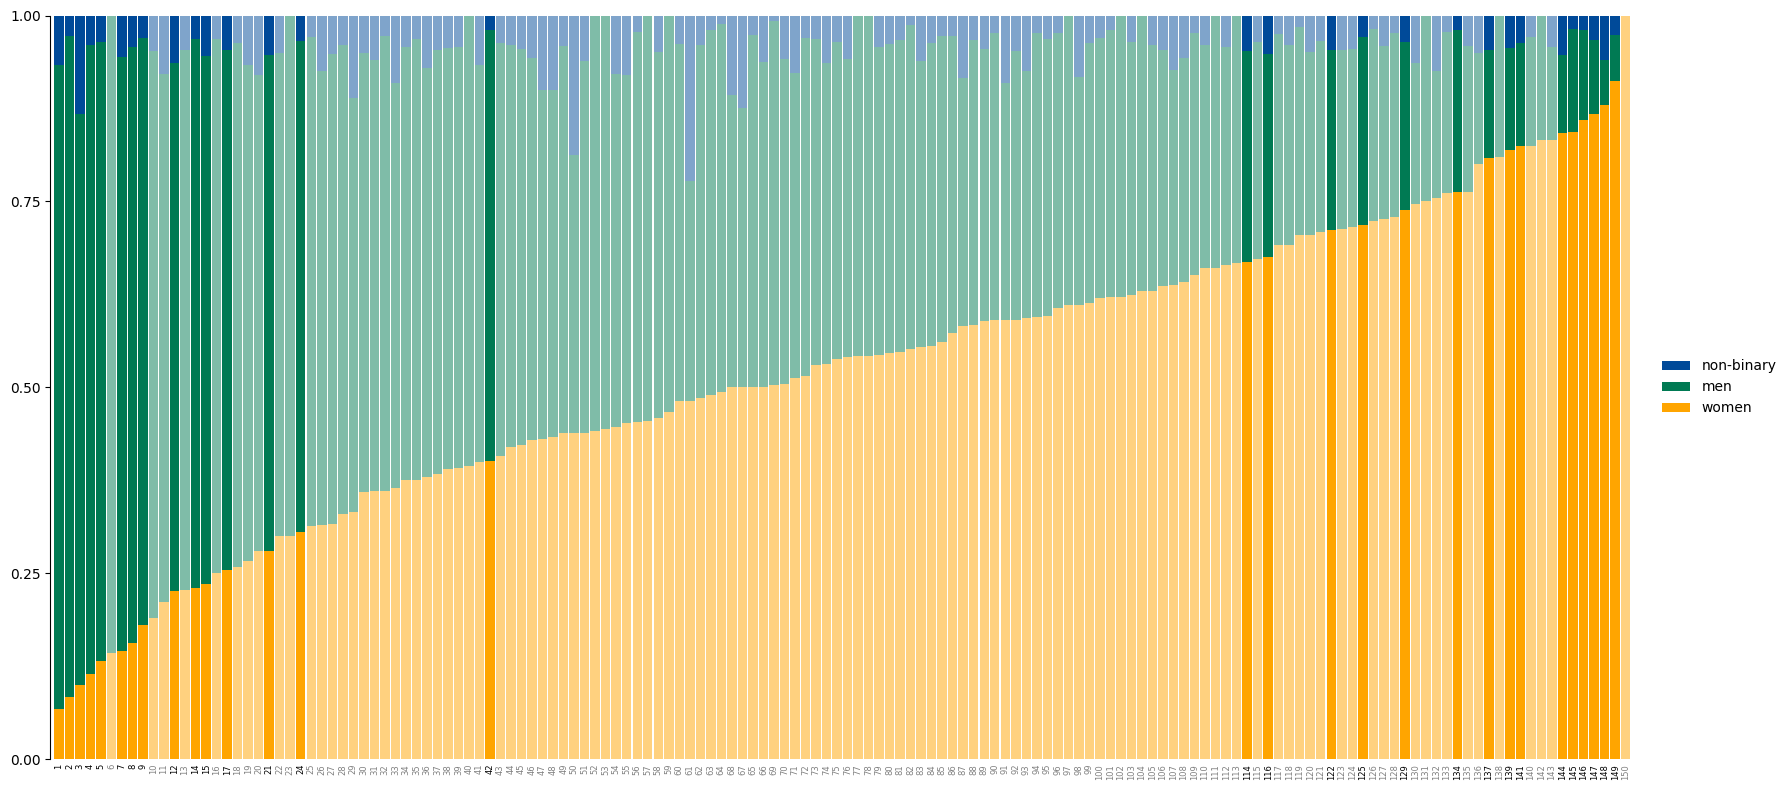

In [11]:
plot_gender_distribution(
    df, 
    filename="gender_distribution_all.png",
    show_counts=False,
    highlight_significant=True 
)

### Distribution of gender across the significant clusters

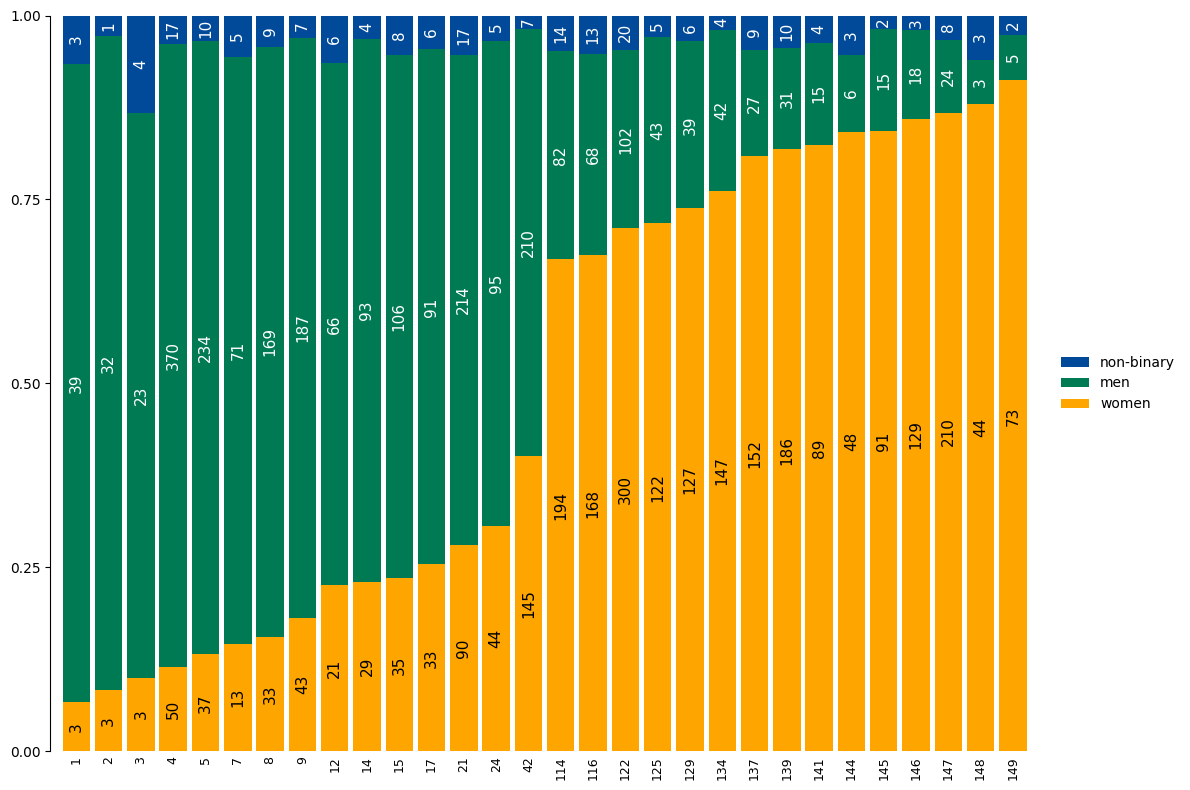

In [12]:
plot_gender_distribution(
    significant_clusters, 
    filename="gender_distribution_significant.png",
    show_counts=True,
    highlight_significant=False 
)

## Let's see some prototype examples


In [13]:
def plot_cluster_prototypes(cluster_ids, filename=None):
    num_clusters = len(cluster_ids)
    
    fig, axes = plt.subplots(
        2, num_clusters, 
        figsize=(3.5 * num_clusters, 7), 
        gridspec_kw={'height_ratios': [12, 1.2], 'hspace': 0.1},
        squeeze=False
    )
    
    for i, cid in enumerate(cluster_ids):
        cluster_data = df[df['cluster_id'] == cid]
        if cluster_data.empty:
            print(f"Warning: Cluster {cid} not found.")
            continue
            
        row = cluster_data.iloc[0]
        ax_skel = axes[0, i]
        ax_bar = axes[1, i]
        
        # skeleton plot title and axis
        ax_skel.set_title(f"Cluster {int(cid)}", pad=15, fontsize=12)
        ax_skel.axis('off')
            
        # draw bones
        for start, end in BONES:
            x_s, x_e = row[f'x_{start}'], row[f'x_{end}']
            y_s, y_e = row[f'y_{start}'], row[f'y_{end}']
            if pd.notna(x_s) and pd.notna(x_e):
                ax_skel.plot([x_s, x_e], [y_s, y_e], color='black', linewidth=1.5)
                
        # draw joints
        for j in JOINTS:
            x_j, y_j = row[f'x_{j}'], row[f'y_{j}']
            if pd.notna(x_j):
                ax_skel.scatter(x_j, y_j, color='black', s=20, zorder=5)
                
        ax_skel.set_aspect('equal', adjustable='datalim')
        ax_skel.invert_yaxis()
        ax_skel.margins(0.15)  # Add 15% room around the skeleton
                
        # stacked proportion bar
        w_pct = row['femalePercent'] / 100.0
        m_pct = row['malePercent'] / 100.0
        nb_pct = row['nonbinaryPercent'] / 100.0
        
        ax_bar.barh(0, w_pct, color=COLOR_WOMEN, edgecolor='none')
        ax_bar.barh(0, m_pct, left=w_pct, color=COLOR_MEN, edgecolor='none')
        ax_bar.barh(0, nb_pct, left=w_pct + m_pct, color=COLOR_NB, edgecolor='none')
        
        ax_bar.set_xlim(0, 1)
        ax_bar.axis('off')
        
        # show counts inside bars
        kwargs = {'fontsize': 11, 'ha': 'center', 'va': 'center'}
        
        ax_bar.text(w_pct / 2, 0, str(int(row['women_count'])), color='black', **kwargs)
        ax_bar.text(w_pct + m_pct / 2, 0, str(int(row['men_count'])), color='white', **kwargs)
        ax_bar.text(w_pct + m_pct + nb_pct / 2, 0, str(int(row['nb_count'])), color='white', **kwargs)
            
    if filename:
        plt.savefig(f"data/output/{filename}", dpi=300, bbox_inches='tight')
    
    plt.show()

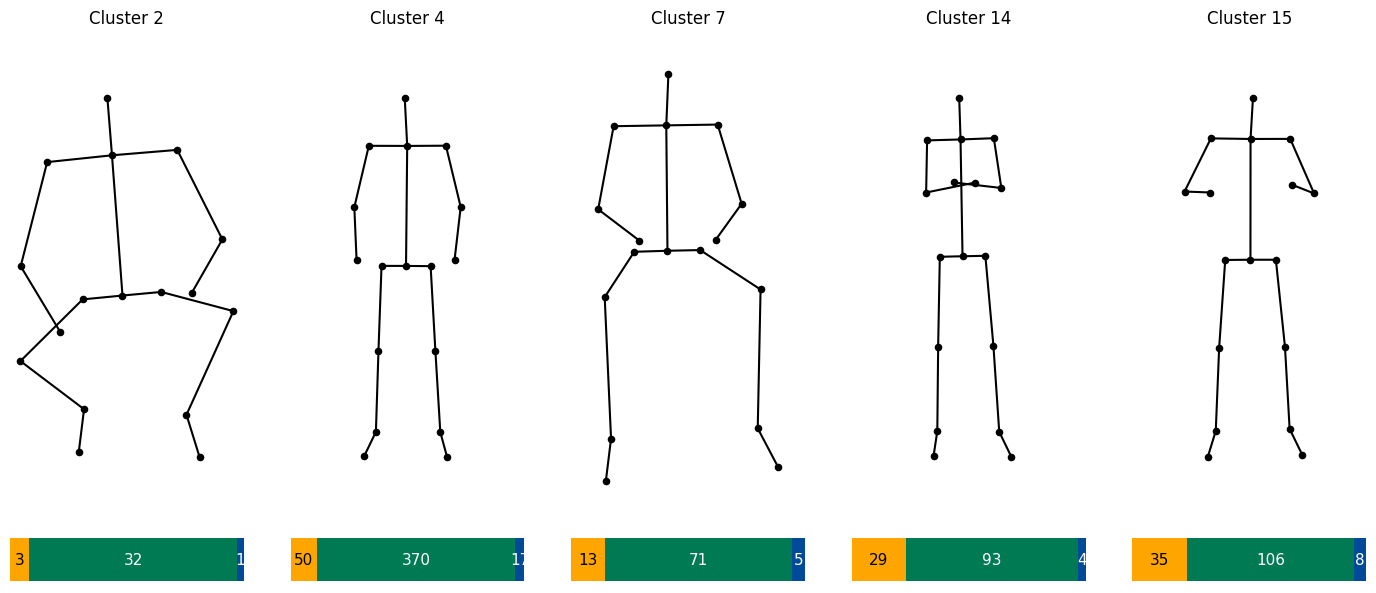

In [14]:
male_clusters = [2, 4, 7, 14, 15] 
plot_cluster_prototypes(male_clusters, filename="male_prototypes.png")

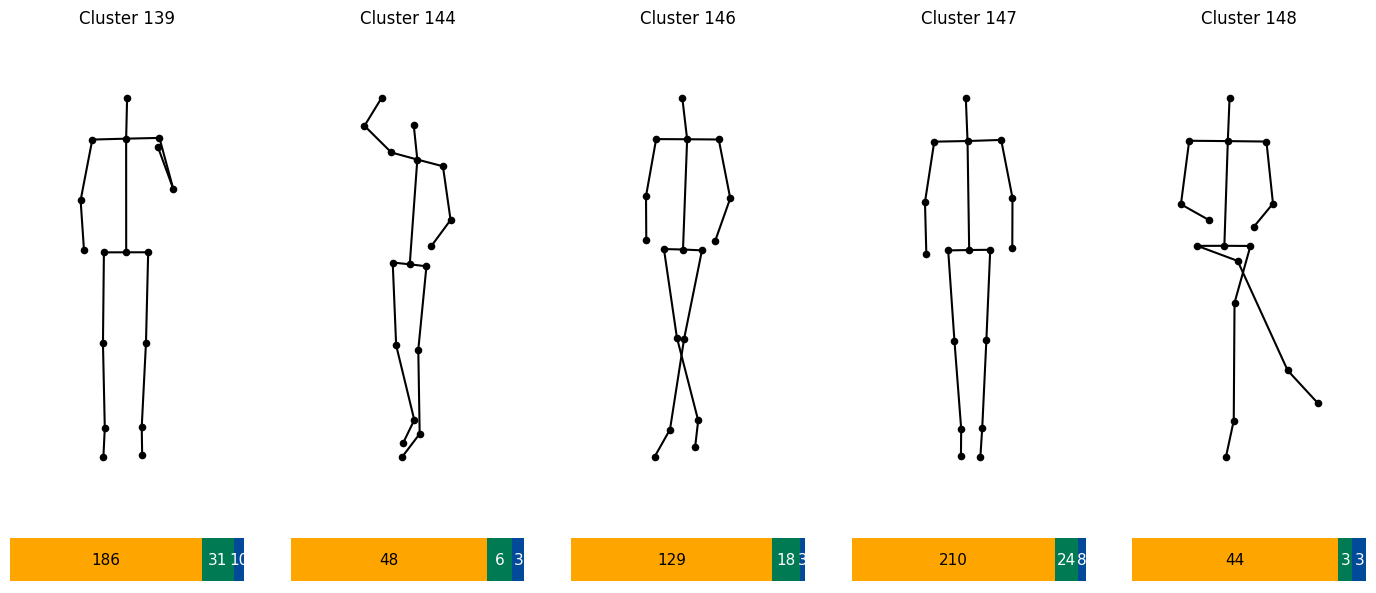

In [15]:
female_clusters = [139, 144, 146, 147, 148]
plot_cluster_prototypes(female_clusters, filename="female_prototypes.png")

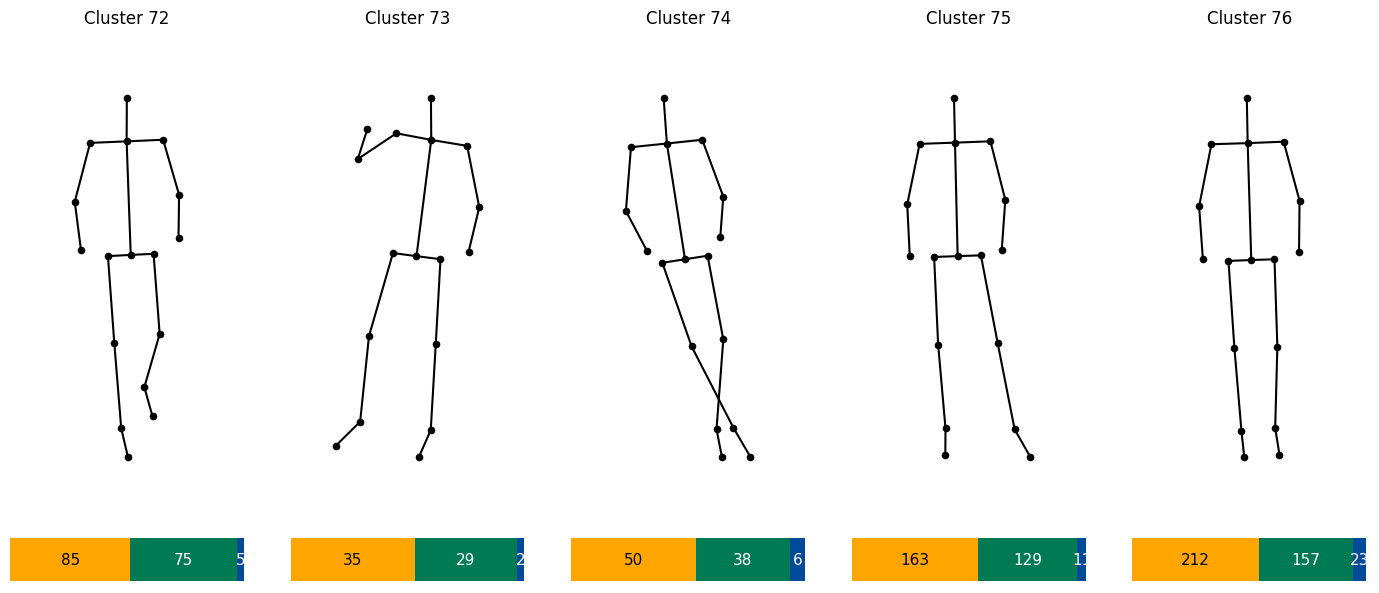

In [16]:
balanced_clusters = [72, 73, 74, 75, 76]
plot_cluster_prototypes(balanced_clusters, filename="non_significant_prototypes.png")